# 🚀 Milestone 4: MLOps & Continuous Monitoring Pipeline
**Project:** Real-Time Object Detection
**Track:** AI & Data Science

### **Objectives:**
1.  **Continuous Monitoring:** Track system latency (FPS) and model confidence in real-time.
2.  **Active Learning:** Automatically capture "Hard Examples" (low-confidence images) to improve the dataset.
3.  **Automated Retraining:** Trigger a retraining loop if model drift is detected.

## 1. Imports & Environment Setup
Importing necessary libraries and ensuring plotting works inline.

In [1]:
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import mlflow

# Ensure plots are displayed within the notebook
%matplotlib inline

print("✅ Environment initialized.")

✅ Environment initialized.


## 2. Configuration & Constants
Centralized configuration. Edit these paths to match your local files.

In [2]:
# --- Configuration ---
EXPERIMENT_NAME = "Real-Time Object Detection"
MODEL_PATH = "best135K.pt"           # Path to your current trained model
VIDEO_SOURCE = "Night_Rainy_Traffic_Video.mp4"  # Path to video file (or 0 for Webcam)

# --- Thresholds ---
CONF_THRESHOLD = 0.25            # Minimum confidence to detect an object
DRIFT_THRESHOLD = 0.40           # If avg confidence drops below this, we flag a drift
HARD_EXAMPLE_RANGE = (0.25, 0.50) # Range to consider an image a "Hard Example"

# --- Output Paths ---
OUTPUT_DIR = Path("mlops_output")
HARD_EXAMPLES_DIR = OUTPUT_DIR / "hard_examples_data" # Where to save edge cases

# Create directories
OUTPUT_DIR.mkdir(exist_ok=True)
HARD_EXAMPLES_DIR.mkdir(exist_ok=True, parents=True)

print(f"✅ Configuration set. Outputs will be saved to: {OUTPUT_DIR}")

✅ Configuration set. Outputs will be saved to: mlops_output


## 3. MLflow Setup
Initializing the experiment tracker.

In [3]:
# Set up MLflow
# We use a local file-based tracking for simplicity. 
# In production, this would be a remote server URI.
mlflow.set_tracking_uri("file:./mlruns") 
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ MLflow Experiment active: {EXPERIMENT_NAME}")

✅ MLflow Experiment active: Real-Time Object Detection


c:\Users\Dark-Soul1\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)


## 4. Define the Monitoring Logic
The core function. It runs the model, calculates FPS, and performs "Hard Example Mining".

In [4]:
def run_monitoring_pipeline(source, model_path, max_frames=300):
    """
    Executes the object detection loop.
    - Tracks FPS (Latency)
    - Tracks Confidence Scores (Accuracy proxy)
    - Saves 'Hard Examples' for active learning
    """
    model = YOLO(model_path)
    cap = cv2.VideoCapture(source)
    
    if not cap.isOpened():
        print(f"❌ Error: Could not open source {source}")
        return [], [], 0, 0

    fps_log = []
    conf_log = []
    frame_count = 0
    hard_count = 0
    
    print(f"🚀 Starting inference on: {source}...")
    
    while cap.isOpened():
        start_time = time.time()
        ret, frame = cap.read()
        if not ret: break
        
        frame_count += 1
        
        # 1. Inference
        results = model(frame, conf=CONF_THRESHOLD, verbose=False)[0]
        
        # 2. Process Detections
        frame_confs = []
        if results.boxes:
            for box in results.boxes:
                conf = float(box.conf)
                cls = int(box.cls)
                label = model.names[cls]
                frame_confs.append(conf)
                
                # 🔥 Active Learning Step 🔥
                # Capture images where the model is unsure (between 0.25 and 0.60)
                if HARD_EXAMPLE_RANGE[0] <= conf < HARD_EXAMPLE_RANGE[1]:
                    img_name = f"hard_{frame_count}_{label}_{conf:.2f}.jpg"
                    cv2.imwrite(str(HARD_EXAMPLES_DIR / img_name), frame)
                    hard_count += 1

        # 3. Calculate Latency (FPS)
        end_time = time.time()
        fps = 1 / (end_time - start_time) if (end_time - start_time) > 0 else 0
        
        fps_log.append(fps)
        avg_conf = np.mean(frame_confs) if frame_confs else 0
        conf_log.append(avg_conf)
        
        # Stop limit (remove this line for full video processing)
        # if frame_count >= max_frames: 
        #     break

    cap.release()
    
    # Global Metrics
    global_avg_conf = np.mean(conf_log) if conf_log else 0
    
    print(f"✅ Inference Finished. Processed {frame_count} frames.")
    print(f"⚠️ Hard Examples Collected: {hard_count}")
    
    return fps_log, conf_log, global_avg_conf, hard_count

## 5. Execute Monitoring Run
Run the pipeline and log metrics to MLflow.

In [5]:
# Start MLflow Context
with mlflow.start_run(run_name="Monitoring_Session_1") as run:
    mlflow.log_param("source", VIDEO_SOURCE)
    mlflow.log_param("model", MODEL_PATH)
    
    # Execute Pipeline
    fps_data, conf_data, avg_conf_score, hard_examples_count = run_monitoring_pipeline(VIDEO_SOURCE, MODEL_PATH)
    
    # Log Summaries
    avg_fps = np.mean(fps_data)
    mlflow.log_metric("avg_fps", avg_fps)
    mlflow.log_metric("avg_confidence", avg_conf_score)
    mlflow.log_metric("hard_examples_count", hard_examples_count)
    
    print(f"📊 Run ID: {run.info.run_id}")
    print(f"📊 Average FPS: {avg_fps:.2f}")
    print(f"📊 Average Confidence: {avg_conf_score:.2f}")

2025/11/30 11:02:29 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



🚀 Starting inference on: Night_Rainy_Traffic_Video.mp4...
✅ Inference Finished. Processed 192 frames.
⚠️ Hard Examples Collected: 1360
📊 Run ID: a6419b7d5bcd485d81f5ea465f61dbe2
📊 Average FPS: 11.52
📊 Average Confidence: 0.50


## 6. Visualization (Reporting)
Create the graphs needed for your PDF report.

📉 Report graphs saved to: mlops_output\monitoring_report.png


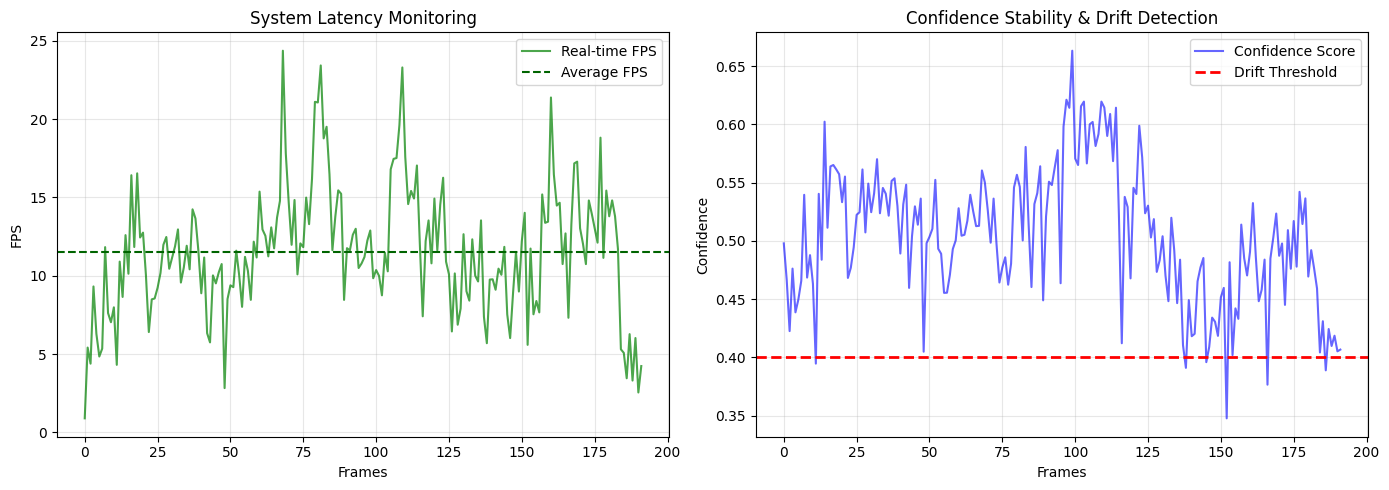

In [6]:
def plot_metrics(fps_list, conf_list, drift_thresh, output_path):
    plt.figure(figsize=(14, 5))

    # Subplot 1: System Latency (FPS)
    plt.subplot(1, 2, 1)
    plt.plot(fps_list, label='Real-time FPS', color='green', alpha=0.7)
    plt.axhline(y=np.mean(fps_list), color='darkgreen', linestyle='--', label='Average FPS')
    plt.title("System Latency Monitoring")
    plt.xlabel("Frames")
    plt.ylabel("FPS")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot 2: Model Accuracy/Drift
    plt.subplot(1, 2, 2)
    plt.plot(conf_list, label='Confidence Score', color='blue', alpha=0.6)
    plt.axhline(y=drift_thresh, color='red', linestyle='--', linewidth=2, label='Drift Threshold')
    plt.title("Confidence Stability & Drift Detection")
    plt.xlabel("Frames")
    plt.ylabel("Confidence")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    save_file = output_path / "monitoring_report.png"
    plt.savefig(save_file)
    print(f"📉 Report graphs saved to: {save_file}")
    plt.show()

# Generate Plots
plot_metrics(fps_data, conf_data, DRIFT_THRESHOLD, OUTPUT_DIR)

## 7. Define Retraining Logic
The function responsible for updating the model.

In [7]:
def automated_retraining(base_model, data_yaml, epochs=5):
    """
    Triggers YOLO training if drift is detected.
    """
    print("🔄 Starting Automated Retraining Pipeline...")
    
    try:
        # Load the base model
        model = YOLO(base_model)
        
        # Check for dataset availability
        if not os.path.exists(data_yaml):
            print(f"⚠️ Warning: '{data_yaml}' not found. Cannot proceed with actual training.")
            return False

        # Run Training
        results = model.train(
            data=data_yaml,
            epochs=epochs,
            imgsz=416,
            project="mlops_retrain",
            name="retrain_run",
            verbose=True
        )
        
        print(f"✅ Retraining Complete. New weights saved at: {results.save_dir}")
        return results.box.map50  # Return the new mAP
            
    except Exception as e:
        print(f"❌ Retraining Failed: {e}")
        return None

## 8. Drift Decision & Trigger
The final MLOps decision logic.

In [11]:
# 1. Analyze for Drift
drift_detected = False

if avg_conf_score < DRIFT_THRESHOLD:
    print(f"🚨 ALERT: Data Drift Detected. Avg Confidence ({avg_conf_score:.2f}) < Threshold ({DRIFT_THRESHOLD})")
    drift_detected = True
elif hard_examples_count > 50:
    print(f"🚨 ALERT: High number of hard examples ({hard_examples_count}). Dataset update required.")
    drift_detected = True
else:
    print(f"✅ System Healthy. No retraining required.")

# 2. Trigger Retraining (Conditional)
if drift_detected:
    print("🚀 Triggering CI/CD Retraining Pipeline...")
    
    # NOTE: You need a valid 'data.yaml' file for this line to run successfully.
    # Uncomment the line below to enable actual training:
    
    # automated_retraining(MODEL_PATH, "data.yaml")

🚨 ALERT: High number of hard examples (1360). Dataset update required.
🚀 Triggering CI/CD Retraining Pipeline...
